# Identity Drift in Hybrid Quantum-Classical Models
## A research notebook starter for Me

> Do hybrid quantum-classical models keep the same decision logic over time, or do they drift under retraining, noise, and perturbation?

It is set up to be:
- reproducible,
- easy to extend,
- clean enough to become the backbone of a paper,
- strong enough to support figures, metrics, and a methods section later.

---

## Core idea

We are **not** only measuring accuracy.

We are measuring whether the model remains the **same model in behavior**, even if its final accuracy looks similar.

### Three kinds of drift
1. **Prediction Drift** — same input, different prediction across runs  
2. **Representation Drift** — internal quantum expectation values change  
3. **Parameter Drift** — learned circuit parameters diverge between runs  

---

## Suggested paper framing

**Working title:**  
**Identity Drift in Hybrid Quantum-Classical Models: Temporal Instability and Representation Change in Variational Circuits**

**Potential claim:**  
Hybrid quantum-classical classifiers may preserve performance while exhibiting substantial behavioral and representational drift across retraining and perturbation.

---

## What this notebook gives you
- synthetic 2D classification dataset
- hybrid quantum-classical model in PennyLane + PyTorch
- repeated training across seeds
- noise / perturbation experiments
- drift metrics
- starter plots

You can later swap in a real dataset if needed.

In [ ]:
# If needed, uncomment and run this once in Colab / Jupyter:
!pip install pennylane torch scikit-learn matplotlib numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 22.9 MB/s eta 0:00:00


In [ ]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Dict, List, Tuple

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import pennylane as qml

print("Torch version:", torch.__version__)
print("PennyLane version:", qml.__version__)

Torch version: 2.10.0+cpu
PennyLane version: 0.44.1


## 1. Reproducibility helpers

You need reproducibility for a paper.  
That means:
- fixed seeds
- clearly separated train/test split
- deterministic experiment settings where possible

In [ ]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)

## 2. Build a simple dataset

We start with a clean, visually understandable dataset.  
For research, that matters because it lets you inspect decision boundaries.

In [ ]:
def make_dataset(n_samples: int = 500, noise: float = 0.15, random_state: int = 42):
    X, y = make_moons(n_samples=n_samples, noise=noise, random_state=random_state)
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=random_state, stratify=y
    )

    return (
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(X_test, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32).view(-1, 1),
        torch.tensor(y_test, dtype=torch.float32).view(-1, 1),
    )

X_train, X_test, y_train, y_test = make_dataset()

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: torch.Size([350, 2]) torch.Size([350, 1])
Test shape: torch.Size([150, 2]) torch.Size([150, 1])


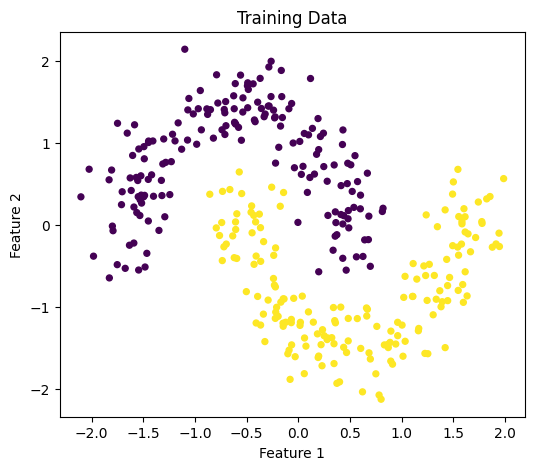

In [ ]:
plt.figure(figsize=(6, 5))
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train.squeeze(), s=18)
plt.title("Training Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## 3. Define the quantum layer

We keep this compact:
- 2 qubits
- angle embedding
- trainable rotations
- expectation values as outputs

These expectation values serve as a kind of **internal representation** for drift analysis.

In [ ]:
N_QUBITS = 2
N_LAYERS = 2

dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')

    for layer in range(N_LAYERS):
        for wire in range(N_QUBITS):
            qml.RY(weights[layer, wire, 0], wires=wire)
            qml.RZ(weights[layer, wire, 1], wires=wire)
        qml.CNOT(wires=[0, 1])

    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

## 4. Hybrid model

The quantum circuit outputs expectation values.  
A small classical layer maps those to a binary prediction.

This makes it easy to inspect:
- final outputs,
- internal expectations,
- learned parameters.

In [ ]:
class HybridQMLModel(nn.Module):
    def __init__(self):
        super().__init__()
        weight_shapes = {"weights": (N_LAYERS, N_QUBITS, 2)}
        self.qlayer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)
        self.classical = nn.Sequential(
            nn.Linear(N_QUBITS, 8),
            nn.Tanh(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        q_out = self.qlayer(x)
        logits = self.classical(q_out)
        return logits

    def get_quantum_representation(self, x):
        with torch.no_grad():
            return self.qlayer(x)

## 5. Training utilities

In [ ]:
@dataclass
class TrainResult:
    seed: int
    model: nn.Module
    train_losses: List[float]
    test_accuracy: float
    test_probs: np.ndarray
    test_preds: np.ndarray
    quantum_repr: np.ndarray
    quantum_weights: np.ndarray

def train_model(seed: int = 42, epochs: int = 50, lr: float = 0.03) -> TrainResult:
    set_seed(seed)
    model = HybridQMLModel()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    losses = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(X_train)
        loss = criterion(logits, y_train)
        loss.backward()
        optimizer.step()
        losses.append(float(loss.item()))

    model.eval()
    with torch.no_grad():
        test_logits = model(X_test)
        test_probs = torch.sigmoid(test_logits).cpu().numpy().flatten()
        test_preds = (test_probs >= 0.5).astype(int)
        acc = accuracy_score(y_test.cpu().numpy().flatten(), test_preds)

        q_repr = model.get_quantum_representation(X_test).cpu().numpy()

    qweights = None
    for name, param in model.named_parameters():
        if "qlayer.weights" in name:
            qweights = param.detach().cpu().numpy().copy()

    return TrainResult(
        seed=seed,
        model=model,
        train_losses=losses,
        test_accuracy=float(acc),
        test_probs=test_probs,
        test_preds=test_preds,
        quantum_repr=q_repr,
        quantum_weights=qweights
    )

## 6. Run multiple training trials

This is where the project starts becoming research.

If two runs reach similar accuracy but produce different:
- predictions,
- quantum representations,
- parameter values,

then your "identity drift" idea has something real behind it.

In [ ]:
seeds = [1, 2, 3, 4, 5]
results = [train_model(seed=s, epochs=60, lr=0.03) for s in seeds]

for r in results:
    print(f"Seed {r.seed}: accuracy = {r.test_accuracy:.4f}")

Seed 1: accuracy = 0.8400
Seed 2: accuracy = 0.8600
Seed 3: accuracy = 0.8800
Seed 4: accuracy = 0.8533
Seed 5: accuracy = 0.8800


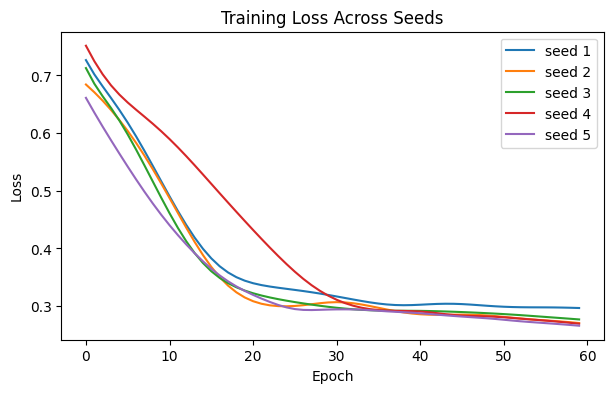

In [ ]:
plt.figure(figsize=(7, 4))
for r in results:
    plt.plot(r.train_losses, label=f"seed {r.seed}")
plt.title("Training Loss Across Seeds")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 7. Define drift metrics

These are the pieces that can become part of your paper.

### Metric 1: Prediction Stability Score (PSS)
How consistent are predictions across runs?

### Metric 2: Representation Drift Score (RDS)
How much do the internal quantum expectation vectors differ between runs?

### Metric 3: Parameter Drift Score (PDS)
How far apart are the trained quantum parameters?

In [ ]:
def prediction_stability_score(results: List[TrainResult]) -> float:
    preds = np.array([r.test_preds for r in results])
    agreement = []

    for i in range(preds.shape[1]):
        values, counts = np.unique(preds[:, i], return_counts=True)
        agreement.append(counts.max() / counts.sum())

    return float(np.mean(agreement))

def pairwise_representation_drift(results: List[TrainResult]) -> np.ndarray:
    n = len(results)
    mat = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            diff = results[i].quantum_repr - results[j].quantum_repr
            mat[i, j] = np.mean(np.linalg.norm(diff, axis=1))
    return mat

def pairwise_parameter_drift(results: List[TrainResult]) -> np.ndarray:
    n = len(results)
    mat = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            diff = results[i].quantum_weights - results[j].quantum_weights
            mat[i, j] = np.linalg.norm(diff)
    return mat

pss = prediction_stability_score(results)
repr_drift = pairwise_representation_drift(results)
param_drift = pairwise_parameter_drift(results)

print("Prediction Stability Score (PSS):", round(pss, 4))
print("Mean pairwise representation drift:", round(repr_drift.mean(), 4))
print("Mean pairwise parameter drift:", round(param_drift.mean(), 4))

Prediction Stability Score (PSS): 0.984
Mean pairwise representation drift: 0.8341
Mean pairwise parameter drift: 6.6875


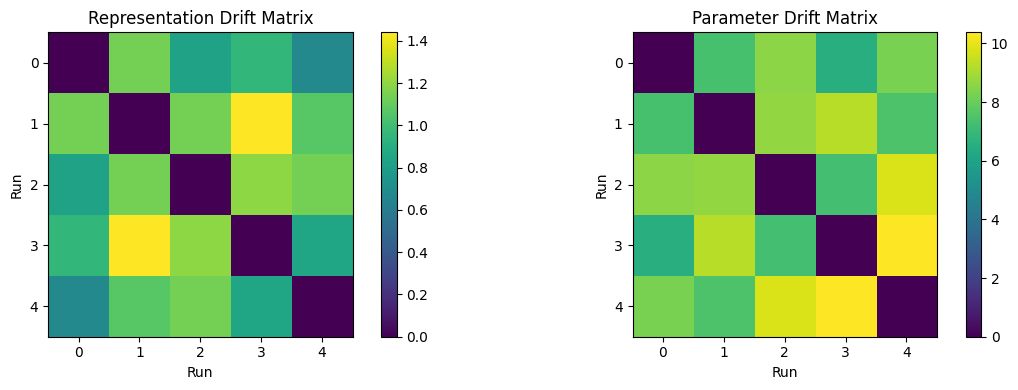

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im1 = axes[0].imshow(repr_drift)
axes[0].set_title("Representation Drift Matrix")
axes[0].set_xlabel("Run")
axes[0].set_ylabel("Run")
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(param_drift)
axes[1].set_title("Parameter Drift Matrix")
axes[1].set_xlabel("Run")
axes[1].set_ylabel("Run")
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

## 8. Visualize decision boundary shifts

A great figure for a paper is showing how the same architecture trained under different seeds produces slightly different boundaries.

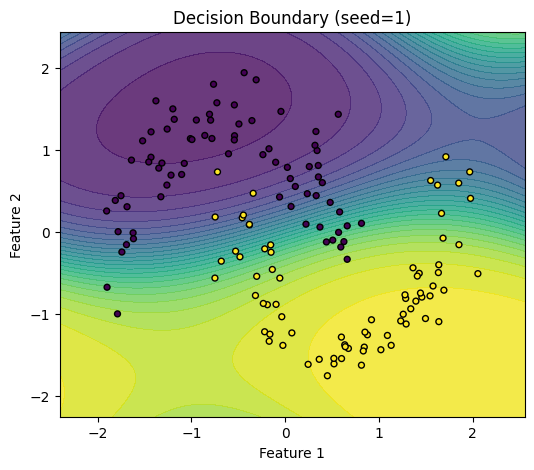

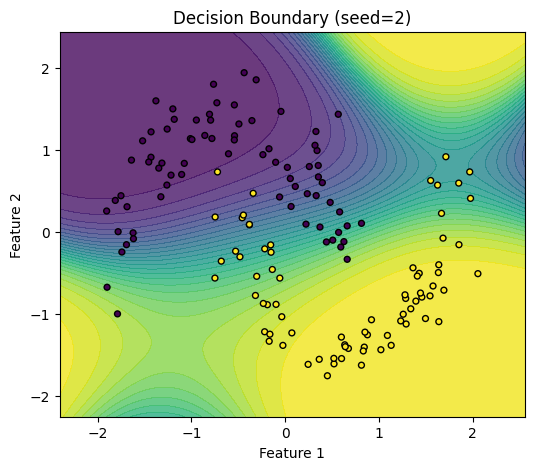

In [ ]:
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    x_min, x_max = X[:, 0].min().item() - 0.5, X[:, 0].max().item() + 0.5
    y_min, y_max = X[:, 1].min().item() - 0.5, X[:, 1].max().item() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

    with torch.no_grad():
        probs = torch.sigmoid(model(grid)).cpu().numpy().reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, probs, levels=30, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), s=18, edgecolors='k')
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

plot_decision_boundary(results[0].model, X_test, y_test, title=f"Decision Boundary (seed={results[0].seed})")
plot_decision_boundary(results[1].model, X_test, y_test, title=f"Decision Boundary (seed={results[1].seed})")

## 9. Perturbation experiment

Now we move beyond seed variation.

We deliberately perturb learned quantum parameters and observe whether the model's outputs drift.

This supports your **temporal / identity drift** framing.

In [ ]:
def clone_model_with_perturbed_quantum_weights(source_model: HybridQMLModel, sigma: float = 0.05, seed: int = 0):
    set_seed(seed)
    cloned = HybridQMLModel()
    cloned.load_state_dict(source_model.state_dict())

    with torch.no_grad():
        for name, param in cloned.named_parameters():
            if "qlayer.weights" in name:
                noise = sigma * torch.randn_like(param)
                param.add_(noise)

    return cloned

base_model = results[0].model
perturbation_levels = [0.0, 0.02, 0.05, 0.1, 0.2]

accs = []
output_drifts = []

with torch.no_grad():
    base_probs = torch.sigmoid(base_model(X_test)).cpu().numpy().flatten()

for sigma in perturbation_levels:
    perturbed = clone_model_with_perturbed_quantum_weights(base_model, sigma=sigma, seed=123)
    with torch.no_grad():
        probs = torch.sigmoid(perturbed(X_test)).cpu().numpy().flatten()
        preds = (probs >= 0.5).astype(int)
        acc = accuracy_score(y_test.cpu().numpy().flatten(), preds)

    output_drift = np.mean(np.abs(base_probs - probs))
    accs.append(acc)
    output_drifts.append(output_drift)

    print(f"sigma={sigma:.2f} | acc={acc:.4f} | mean output drift={output_drift:.4f}")

sigma=0.00 | acc=0.8400 | mean output drift=0.0000
sigma=0.02 | acc=0.8400 | mean output drift=0.0077
sigma=0.05 | acc=0.8467 | mean output drift=0.0191
sigma=0.10 | acc=0.8400 | mean output drift=0.0370
sigma=0.20 | acc=0.8400 | mean output drift=0.0693


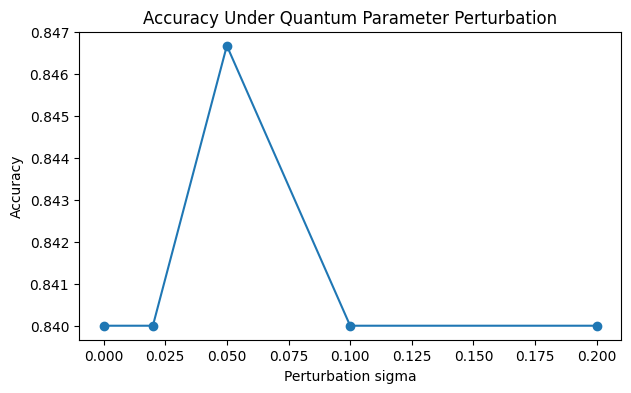

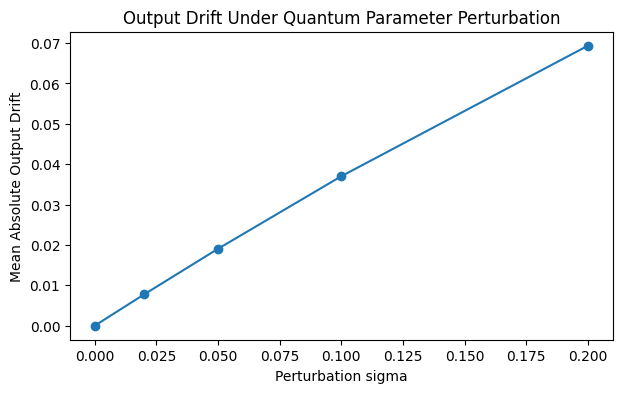

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(perturbation_levels, accs, marker='o')
plt.title("Accuracy Under Quantum Parameter Perturbation")
plt.xlabel("Perturbation sigma")
plt.ylabel("Accuracy")
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(perturbation_levels, output_drifts, marker='o')
plt.title("Output Drift Under Quantum Parameter Perturbation")
plt.xlabel("Perturbation sigma")
plt.ylabel("Mean Absolute Output Drift")
plt.show()

## 10. Optional extension: "identity consistency" metric

This combines behavior + representation.

You can refine this later for the paper.

In [ ]:
def identity_consistency_index(results: List[TrainResult]) -> float:
    # Higher is better / more stable
    pss = prediction_stability_score(results)
    repr_drift = pairwise_representation_drift(results).mean()
    param_drift = pairwise_parameter_drift(results).mean()

    # Simple normalized style score for starter use
    score = pss / (1.0 + repr_drift + 0.1 * param_drift)
    return float(score)

ici = identity_consistency_index(results)
print("Identity Consistency Index (ICI):", round(ici, 4))

Identity Consistency Index (ICI): 0.3931


## 11. What to write down while you work

As you build results, keep notes on:
- Which seeds produce similar accuracy but different boundaries?
- Does representation drift happen even when prediction drift is small?
- Is parameter drift always large, or only under some settings?
- Does perturbation damage performance immediately, or only after a threshold?

These observations become:
- your Results section,
- figure captions,
- and eventually your discussion.

## 12. Real publication upgrade path

To make this notebook stronger, next steps could be:

### A. Add a classical baseline
Train a tiny MLP on the same data and compare drift.

### B. Add multiple datasets
- moons
- circles
- simple tabular dataset

### C. Add noise models
Use noisy devices or channel simulation where available.

### D. Repeat over multiple circuit depths
See whether deeper circuits drift more or less.

### E. Save experiment logs
Export metrics to CSV for later figures and tables.

In [ ]:
# Example: quick classical baseline for comparison

class ClassicalMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 8),
            nn.Tanh(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.net(x)

def train_classical(seed: int = 42, epochs: int = 60, lr: float = 0.03):
    set_seed(seed)
    model = ClassicalMLP()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for _ in range(epochs):
        optimizer.zero_grad()
        logits = model(X_train)
        loss = criterion(logits, y_train)
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        probs = torch.sigmoid(model(X_test)).cpu().numpy().flatten()
        preds = (probs >= 0.5).astype(int)
        acc = accuracy_score(y_test.cpu().numpy().flatten(), preds)
    return acc, preds, probs

classical_runs = [train_classical(seed=s) for s in seeds]
print("Classical accuracies:", [round(r[0], 4) for r in classical_runs])

Classical accuracies: [0.8733, 0.86, 0.8533, 0.88, 0.86]


## 13. Draft language for your paper

### Possible research question
How stable are hybrid quantum-classical classifiers under repeated retraining and controlled parameter perturbation?

### Possible hypothesis
Hybrid quantum models can maintain comparable predictive accuracy while exhibiting measurable internal drift across runs, suggesting that standard performance metrics alone may hide instability.

### Possible contribution statement
We introduce a simple experimental framework for quantifying behavioral and representational drift in variational quantum classifiers using repeated trials, internal expectation-value analysis, and parameter perturbation studies.

## 14. Final note

This is a **starter notebook**, not the final paper.  
Its purpose is to help you move from “cool idea” to:

- runnable experiment,
- first plots,
- first metrics,
- first methods section.

Once this runs cleanly, the next stage is:
1. tighten the definitions,
2. add a classical comparison,
3. run more seeds,
4. export figures,
5. start writing the introduction and results.

Good research starts by making the idea measurable.